In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import xarray as xr
from pathlib import Path
import importlib


# ============================================================
# HARD-CODED PROJECT PATHS
# Notebook location:
# THESIS/z.flow_postprocessing/notebooks/calculate_EDS_adjusted.ipynb
# ============================================================

NB_DIR = Path.cwd()

PROJECT_DIR = NB_DIR.parent.parent
OGCM_DIR = PROJECT_DIR / "OGCM"
OGCM_SCRIPTS_DIR = OGCM_DIR / "scripts"
THEME_DIR = PROJECT_DIR / "theme"

for path in [PROJECT_DIR, OGCM_SCRIPTS_DIR]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Notebook dir     : {NB_DIR}")
print(f"Project dir      : {PROJECT_DIR}")
print(f"OGCM scripts dir : {OGCM_SCRIPTS_DIR}")
print(f"Theme dir        : {THEME_DIR}")


# ============================================================
# IMPORT PROJECT MODULES
# ============================================================

import theme.plot_theme as ptheme
import ocean_analysis as oa

importlib.reload(ptheme)
ptheme.apply_theme()

importlib.reload(oa)

Notebook dir     : c:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\notebooks
Project dir      : c:\Users\Jelle Gortemaker\Documents\Thesis
OGCM scripts dir : c:\Users\Jelle Gortemaker\Documents\Thesis\OGCM\scripts
Theme dir        : c:\Users\Jelle Gortemaker\Documents\Thesis\theme


c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


<module 'ocean_analysis' from 'c:\\Users\\Jelle Gortemaker\\Documents\\Thesis\\OGCM\\scripts\\ocean_analysis.py'>

In [ ]:
# ============================================================
# CASE SETTINGS
# ============================================================

case_name = "run_jun1_parcels"
sim_name = "Case JUN-1 Production"
SAVE = False  

DATA_FILE = (NB_DIR / f"../data/input/{case_name}.nc").resolve()

# All figures are saved directly inside ../results/<case_name>/
RESULTS_DIR = (NB_DIR / f"../results/{case_name}").resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def save_case_figure(fig, figure_name, dpi=300, ext="png", close=False):
    """
    Save a figure inside ../results/<case_name>/.

    Example
    -------
    save_case_figure(fig, "EDS_overview_T3")
    """
    if not SAVE:
        return None

    figure_name = str(figure_name).replace(" ", "_")
    out_path = RESULTS_DIR / f"{figure_name}.{ext}"

    fig.savefig(
        out_path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )

    if close:
        plt.close(fig)

    print(f"Saved figure to: {out_path}")
    return out_path


<xarray.Dataset> Size: 471MB
Dimensions:      (Zmd000001: 1, T: 224, Y: 512, Xp1: 513, Yp1: 513, X: 512)
Coordinates:
  * T            (T) float64 2kB 5.4e+03 1.62e+04 ... 2.403e+06 2.414e+06
  * Y            (Y) float64 4kB 250.0 750.0 1.25e+03 ... 2.552e+05 2.558e+05
  * Xp1          (Xp1) float64 4kB 0.0 500.0 1e+03 ... 2.555e+05 2.56e+05
  * Yp1          (Yp1) float64 4kB 0.0 500.0 1e+03 ... 2.555e+05 2.56e+05
  * X            (X) float64 4kB 250.0 750.0 1.25e+03 ... 2.552e+05 2.558e+05
Dimensions without coordinates: Zmd000001
Data variables:
    diag_levels  (Zmd000001) float64 8B ...
    iter         (T) int32 896B ...
    UVEL         (T, Zmd000001, Y, Xp1) float32 235MB ...
    VVEL         (T, Zmd000001, Yp1, X) float32 235MB ...
Attributes: (12/18)
    MITgcm_version:  checkpoint69l
    build_user:      jgortemaker
    build_host:      cmp001
    build_date:      Wed Apr 15 08:41:50 CEST 2026
    MITgcm_URL:      http://mitgcm.org
    MITgcm_tag_id:   
    ...              .

c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


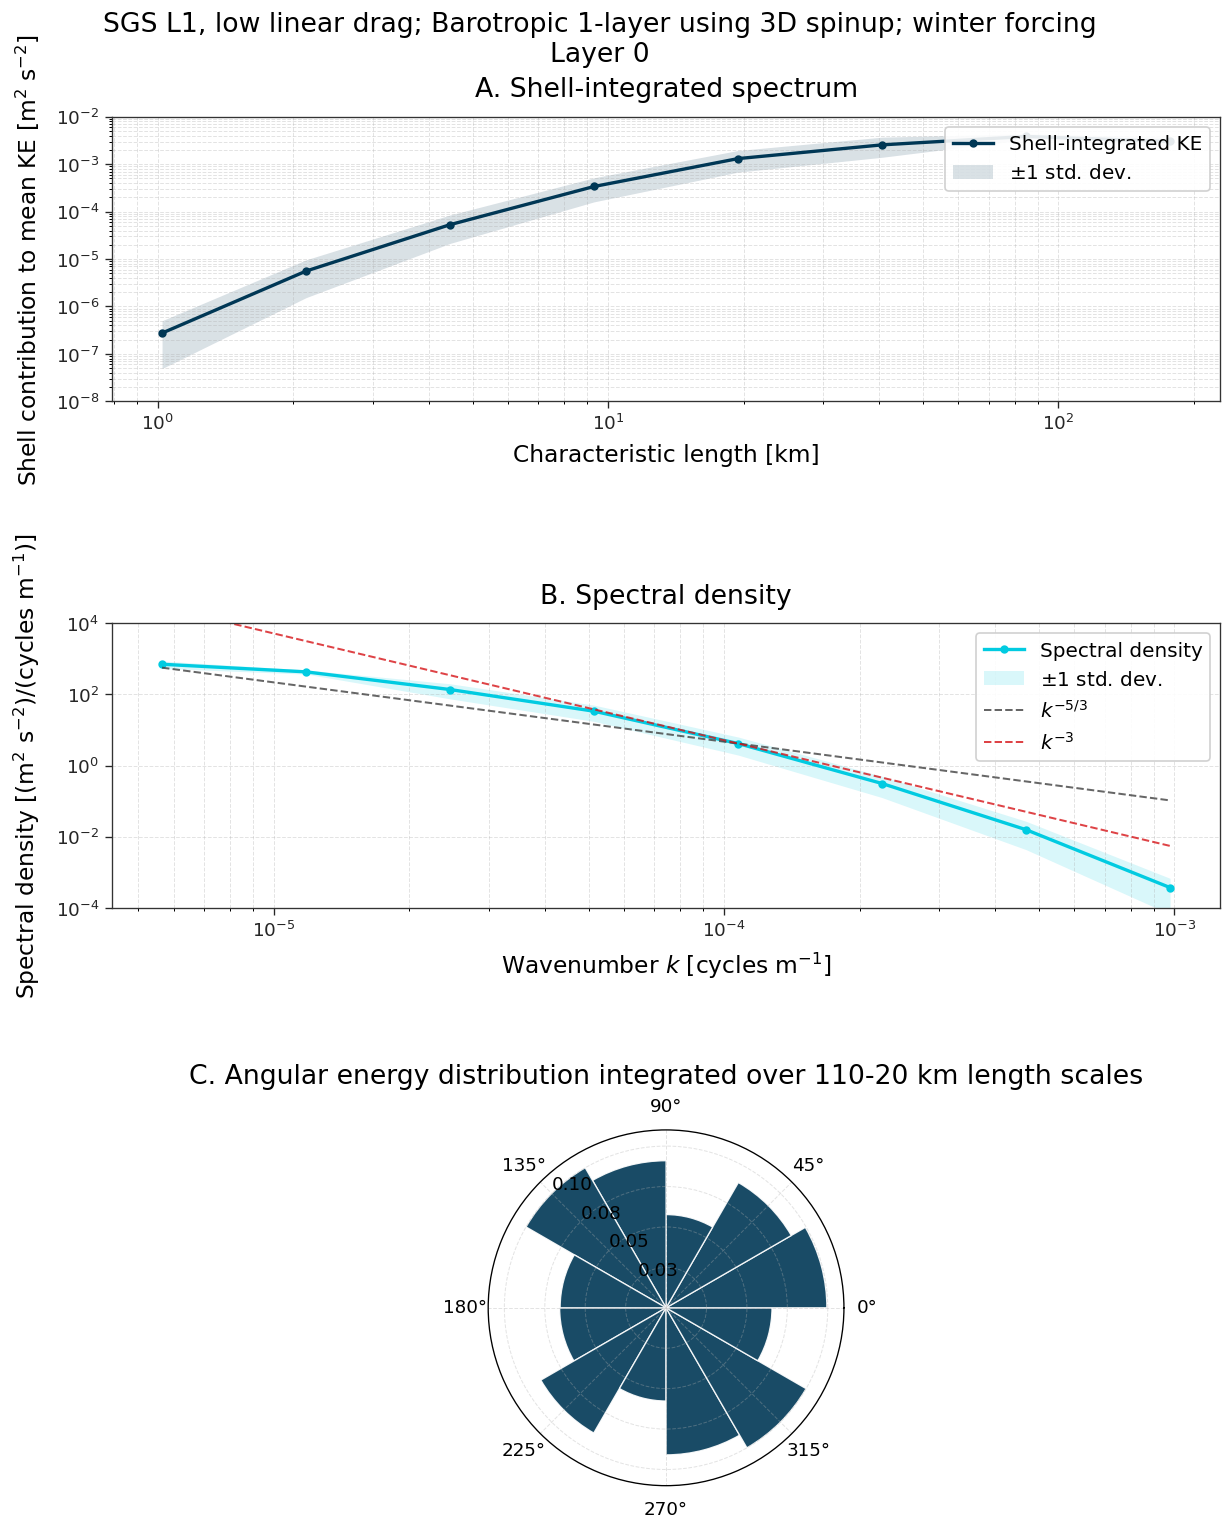

In [ ]:
# ============================================================
# SINGLE INITIALIZED-SIMULATION EDS OVERVIEW
# ============================================================

eds_init = oa.calculate_EDS_init(
    DATA_FILE,
    target_box=None,
    max_wavelength_km=None,
    x_res=500,
    y_res=500,
    n_bins=8,
    remove_mean=True,
    min_modes_per_bin=3,
    rose_scale_bands_km=[(110, 20)],
    rose_n_angle_bins=12,
    snapshot_index=None,
    layer_index=0,
)

if eds_init.attrs["snapshot_time_index"] is not None:
    n_days = eds_init.attrs["snapshot_time_index"] / 2
    title = f"{sim_name} (T = {n_days:g} days)"
    time_label = f"T{eds_init.attrs['snapshot_time_index']}"
else:
    title = sim_name
    time_label = "all_timesteps"

fig = oa.plot_eds_overview(
    eds_init,
    title=title,
    ylim_a=(1e-8, 1e-2),      # subplot A y-axis range
    ylim_b=(1e-4, 1e4),       # subplot B y-axis range
    show=True,
)

save_case_figure(
    fig,
    f"{case_name}_{time_label}_EDS_overview",
)


c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\

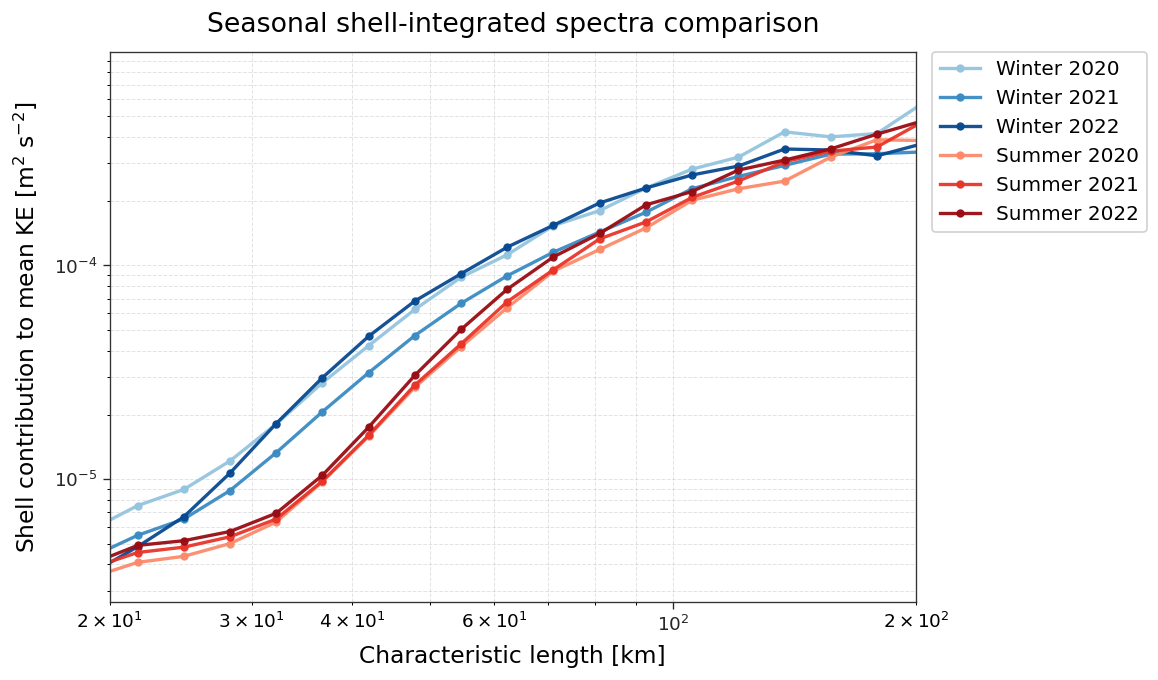

In [ ]:
# ============================================================
# SEASONAL EDS PLOT
# ============================================================
# Edit paths/years here. This section uses GLORYS-style files through oa.calculate_EDS().

seasonal_data_groups = {
    "Winter": {
        "2020": "../../OGCM/data/input/GPGP_jan2020.nc",
        "2021": "../../OGCM/data/input/GPGP_jan2021.nc",
        "2022": "../../OGCM/data/input/GPGP_jan2022.nc",
    },
    "Summer": {
        "2020": "../../OGCM/data/input/GPGP_aug2020.nc",
        "2021": "../../OGCM/data/input/GPGP_aug2021.nc",
        "2022": "../../OGCM/data/input/GPGP_aug2022.nc",
    },
}

# Target box for seasonal comparison.
# Use None for whole domain, or e.g. [lon_w, lon_e, lat_s, lat_n].
seasonal_target_box = None

missing_files = []
for season, years in seasonal_data_groups.items():
    for year, rel_path in years.items():
        candidate = (NB_DIR / rel_path).resolve()
        if not candidate.exists():
            missing_files.append(str(candidate))

if missing_files:
    print("Seasonal plot skipped because these files were not found:")
    for path in missing_files:
        print("  -", path)
else:
    fig_seasonal, ax_seasonal = oa.plot_EDS_seasonal(
        data_groups=seasonal_data_groups,
        target_box=seasonal_target_box,
        initialized_velocity=False,
        max_wavelength_km=None,
        n_bins=40,
        remove_mean=True,
        temporal_window_days=1,
        temporal_skip_days=0,
        temporal_stride_days=1,
        min_modes_per_bin=3,
        spectrum_var="shell_integrated_spectrum",
        title="Seasonal shell-integrated spectra comparison",
        xlim_km=(20, 200),
        ylim=None,  # set manually if desired, e.g. (1e-8, 1e-2)
        show=True,
    )

    save_case_figure(
        fig_seasonal,
        f"{case_name}_seasonal_shell_integrated_spectra",
    )
